In [10]:
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Load dataset
import os
os.listdir('/kaggle/input/datasets/organizations/nih-chest-xrays/data')

['images_003',
 'images_012',
 'LOG_CHESTXRAY.pdf',
 'README_CHESTXRAY.pdf',
 'BBox_List_2017.csv',
 'images_009',
 'images_008',
 'images_007',
 'test_list.txt',
 'images_010',
 'ARXIV_V5_CHESTXRAY.pdf',
 'images_002',
 'images_011',
 'Data_Entry_2017.csv',
 'images_001',
 'train_val_list.txt',
 'images_005',
 'FAQ_CHESTXRAY.pdf',
 'images_004',
 'images_006']

In [12]:
# load metadata csv
import pandas as pd
csv_path = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
df = pd.read_csv(csv_path)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [13]:
# Drop unnecessary columns
df = df.drop(columns=['Follow-up #','Patient Age','Patient Gender',
                      'View Position','OriginalImage[Width','Height]',
                      'OriginalImagePixelSpacing[x','y]','Unnamed: 11'
])
df.head()

,Image Index,Finding Labels,Patient ID
0,00000001_000.png,Cardiomegaly,1
1,00000001_001.png,Cardiomegaly|Emphysema,1
2,00000001_002.png,Cardiomegaly|Effusion,1
3,00000002_000.png,No Finding,2
4,00000003_000.png,Hernia,3


In [14]:
# Mapping Image index to Image path using glob
import glob
image_paths = glob.glob("/kaggle/input/datasets/organizations/nih-chest-xrays/data/images*/images/*.png")
path_map = {p.split("/")[-1]: p for p in image_paths}
df["path"] = df["Image Index"].map(path_map)
df.head()

,Image Index,Finding Labels,Patient ID,path
0,00000001_000.png,Cardiomegaly,1,/kaggle/input/datasets/organizations/nih-chest...
1,00000001_001.png,Cardiomegaly|Emphysema,1,/kaggle/input/datasets/organizations/nih-chest...
2,00000001_002.png,Cardiomegaly|Effusion,1,/kaggle/input/datasets/organizations/nih-chest...
3,00000002_000.png,No Finding,2,/kaggle/input/datasets/organizations/nih-chest...
4,00000003_000.png,Hernia,3,/kaggle/input/datasets/organizations/nih-chest...


In [15]:
# Count no. of diseases per row/image
df["num_labels"] = df["Finding Labels"].apply(lambda x: len(x.split("|")))
df[["Finding Labels", "num_labels"]].head()

,Finding Labels,num_labels
0,Cardiomegaly,1
1,Cardiomegaly|Emphysema,2
2,Cardiomegaly|Effusion,2
3,No Finding,1
4,Hernia,1


In [16]:
# Reducing classification problem from 14 classes multi-label classification to 5 classes multi-class classification
selected_classes = ["No Finding", "Effusion", "Atelectasis", "Cardiomegaly", "Pneumothorax"]

df = df[(df["num_labels"]==1) & (df["Finding Labels"].isin(selected_classes))]

df["Finding Labels"].value_counts()

Finding Labels
No Finding      60361
Atelectasis      4215
Effusion         3955
Pneumothorax     2194
Cardiomegaly     1093
Name: count, dtype: int64

In [18]:
df.sample(5)

,Image Index,Finding Labels,Patient ID,path,num_labels
67411,00016646_002.png,No Finding,16646,/kaggle/input/datasets/organizations/nih-chest...,1
64358,00015883_000.png,Effusion,15883,/kaggle/input/datasets/organizations/nih-chest...,1
81043,00019903_000.png,No Finding,19903,/kaggle/input/datasets/organizations/nih-chest...,1
76817,00018865_037.png,No Finding,18865,/kaggle/input/datasets/organizations/nih-chest...,1
10169,00002639_006.png,Effusion,2639,/kaggle/input/datasets/organizations/nih-chest...,1


In [34]:
df.iloc[64358].path

'/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_011/images/00026486_002.png'

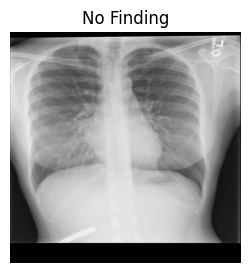

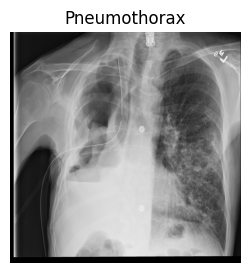

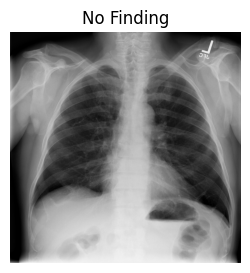

In [12]:
# Visulizing sample images
import cv2
import matplotlib.pyplot as plt

sample_rows = df.sample(3)

for _, row in sample_rows.iterrows():
    
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(row["Finding Labels"])
    plt.axis("off")

In [21]:
# Image processing function
import cv2
import numpy as np

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    original_img = img.copy()
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img/255.0

    img_array = np.expand_dims(img, axis=0) # since model expects data in batch
    
    return img_array, original_img

In [ ]:
# Loading model and displaying last 10 model layers
import tensorflow as tf

model_path = '/kaggle/input/models/amruta08/trained-model/keras/default/1/best_model.keras'
model = tf.keras.models.load_model(model_path)

for layer in model.layers[-10:]:
    print(layer.name)

conv5_block16_0_relu
conv5_block16_1_conv
conv5_block16_1_bn
conv5_block16_1_relu
conv5_block16_2_conv
conv5_block16_concat
bn
relu
global_average_pooling2d
dense


In [27]:
last_conv_layer = "conv5_block16_concat"

In [24]:
def compute_heatmap(img_array, model, last_conv_layer):
    # 1. Creating a model that gives last conv layer output + predicitons
    grad_model = tf.keras.models.Model(
        inputs = model.inputs,
        outputs = [
            model.get_layer(last_conv_layer).output,
            model.output
        ]
    )
    
    # 2. Tracking Gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    # 3. Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)
    
    # 4. Average gradients (1, 7, 7, 1024) → (1024,)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    
    # 5. Multiply feature maps by importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # 6. Normalize
    heatmap = tf.maximum(heatmap, 0)/tf.reduce_max(heatmap)
    
    return heatmap.numpy(), pred_index.numpy()

In [25]:
def generate_gradcam(img_path, model, last_conv_layer, output_path):
    # Preprocess image
    img_array, original_img = preprocess_image(img_path)

    # Generate heatmap
    heatmap, pred_index = compute_heatmap(img_array, model, last_conv_layer)
    
    # Resize
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    
    # Color map
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Overlay heatmap 
    output_img = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)
    
    # Save image
    cv2.imwrite(output_path, output_img)
    
    return output_path, pred_index
    

Prediction index: 0


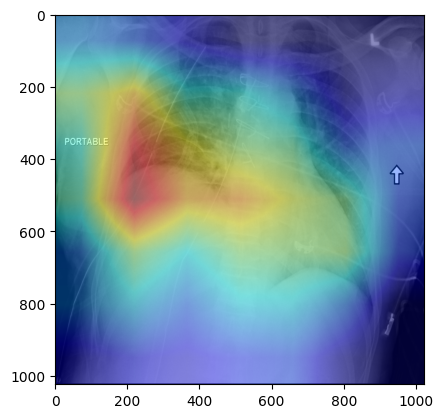

In [35]:
import matplotlib.pyplot as plt

img_path = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_011/images/00026486_002.png'

output_path, pred = generate_gradcam(
    img_path,
    model,
    last_conv_layer,
    "gradcam_output.png"
)

gradcam_op = cv2.imread("/kaggle/working/gradcam_output.png")
gradcam_op = cv2.cvtColor(gradcam_op, cv2.COLOR_BGR2RGB)
plt.imshow(gradcam_op)
print("Prediction index:", pred)